# Bước 05b: Thực nghiệm Chứng minh các Tham số Hardcode
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU

Tài liệu `docs/2026_08_06_Chung_Minh_Toan_Bo_Tham_So_Hardcode.md` đã chứng minh các hằng số
bằng **lý thuyết** (vật lý khí quyển, tiêu chuẩn PVLIB/Sandia, các bài báo IEEE/MDPI).

Notebook này chứng minh bằng **thực nghiệm**: với mỗi tham số, ta quét qua nhiều giá trị,
train lại mô hình và đo WAPE thực tế, rồi lập bảng đối chiếu. Mục đích là trả lời được câu
hỏi của hội đồng *"tại sao lại chọn đúng con số đó?"* bằng số liệu đo được trên chính bộ
dữ liệu 42 trạm, chứ không chỉ bằng trích dẫn.

**Nguyên tắc:** mọi thí nghiệm đều chạy trên **tập validation**, tuyệt đối không đụng tập
test — tập test chỉ được mở duy nhất một lần ở notebook 07.

### Các tham số được thực nghiệm

| Tham số | Giá trị đang dùng | Nằm ở |
|---|---|---|
| `eps_elev` | 0.05 | `features.yaml` — ngưỡng sin(góc cao) coi là ban ngày |
| `clip_csi` | 1.5 | `features.yaml` — trần chỉ số trời quang khi downscale bức xạ |
| `k_target_max` | 1.5 | `train.yaml` — trần mục tiêu đã chuẩn hoá |
| `tran_cong_suat_he_so` | 1.02 | `train.yaml` — cho phép vượt trần công suất 2% |
| `he_so_trong_so_dinh` | 1.0 | `train.yaml` — tăng trọng số vùng đỉnh |
| `quantile_scale` | 0.99 | `features.yaml` — phân vị tính `site_scale` |


## 2. Import thư viện và nạp cấu hình pipeline

In [1]:
# Notebook nay THU NGHIEM tren chinh code pipeline dang chay, nen import thang tu do -
# neu chep lai code ra day thi thu nghiem se do mot ban sao, khong con y nghia chung minh.
import os
for _b in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
           'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_b, '6')

import copy
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

PIPELINE = Path('../../srcs/05_machine_learning/pipeline').resolve()
sys.path.insert(0, str(PIPELINE))

from core.config import load_config
from core.context import Ctx
from core.paths import Paths
from core.lgbm import fit_an_toan, kiem_tra_gpu, them_tham_so_gpu
from core.metrics import compute_metrics
from stages import s08a_prepare, s08e_metrics_val

CFG_GOC = load_config()
LOSS = 'huber'      # mo hinh vo dich - thu nghiem tren chinh no moi co y nghia
HORIZON = 1
OUTPUT_DIR = '../../data/model/v4/05b_thuc_nghiem_tham_so'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Da nap cau hinh pipeline.")
print(f"- Loss thu nghiem : {LOSS} (h{HORIZON})")
print(f"- Thu muc ket qua : {OUTPUT_DIR}")
print(f"- Thiet bi        : {'GPU' if CFG_GOC.runtime['gpu']['use_gpu'] else 'CPU'}"
      f" | deterministic = {CFG_GOC.runtime['lightgbm'].get('deterministic')}")


Da nap cau hinh pipeline.
- Loss thu nghiem : huber (h1)
- Thu muc ket qua : ../../data/model/v4/05b_thuc_nghiem_tham_so
- Thiet bi        : CPU | deterministic = True


## 3. Hàm chạy một thí nghiệm

Mỗi thí nghiệm = đổi **đúng một** tham số trong cấu hình → dựng lại ma trận huấn luyện →
train → đo WAPE trên tập validation. Mọi thứ khác giữ nguyên, nên chênh lệch WAPE quy được
về đúng tham số đang xét.

### Hai điều kiện bắt buộc để phép so sánh có giá trị

**(1) Dùng siêu tham số trung lập, không dùng kết quả Optuna.**
Bộ siêu tham số trong `best_params.json` được Optuna tìm ra **trong khi các hằng số đang
mang giá trị hiện tại**. Nếu dùng nó để chấm điểm các giá trị khác thì giá trị đang dùng
được lợi thế sẵn: siêu tham số đã tối ưu riêng cho nó. Vì vậy mọi thí nghiệm ở đây đều dùng
`default_params` trong `train.yaml` — cùng một bộ cho tất cả, không giá trị nào được ưu ái.

**(2) Cố định phạm vi đánh giá.**
Riêng `eps_elev` vừa quyết định dòng nào vào tập train, vừa quyết định dòng nào được chấm
điểm. Ngưỡng càng cao thì càng cắt bớt vùng bình minh/hoàng hôn — vốn là vùng khó dự báo
nhất — nên WAPE đẹp lên do bài toán dễ đi chứ không phải do mô hình tốt hơn. Để so được,
phần đo luôn dùng **ngưỡng gốc** (`EPS_CHUAN`), chỉ phần huấn luyện mới đổi theo giá trị
đang thử.

In [2]:
EPS_CHUAN = float(CFG_GOC.features['eps_elev'])   # nguong dung de CO DINH pham vi do


def chay_1_thi_nghiem(duong_dan_khoa, gia_tri, nhan=''):
    """Doi DUNG MOT tham so roi train lai, tra ve dict ket qua.

    duong_dan_khoa: vd ('features', 'eps_elev') hoac ('train', 'k_target_max')
    """
    cfg = copy.deepcopy(CFG_GOC)
    phan, khoa = duong_dan_khoa
    goc = getattr(cfg, phan)[khoa]
    getattr(cfg, phan)[khoa] = gia_tri

    # (1) Tat Optuna: moi thi nghiem dung chung default_params -> khong gia tri nao duoc
    #     loi the tu bo sieu tham so da tuning rieng cho no.
    cfg.train['use_best_params_if_exists'] = False

    ctx = Ctx(cfg=cfg, paths=Paths(cfg), loss_name=LOSS, horizon_steps=HORIZON)
    t0 = time.time()
    s08a_prepare.chuan_bi(ctx)

    gpu, _ = kiem_tra_gpu(cfg)
    tho, nguon_tham_so = cfg.sieu_tham_so(LOSS, HORIZON)
    ctx.model, _ = fit_an_toan(them_tham_so_gpu(tho, cfg, gpu), ctx.X_dev, ctx.y_dev,
                               sample_weight=ctx.w_dev, cfg=cfg)

    # (2) Do tren pham vi CO DINH: dung lai cfg voi eps_elev goc, chi phan train moi doi
    cfg_do = copy.deepcopy(cfg)
    cfg_do.features['eps_elev'] = EPS_CHUAN
    ctx_do = Ctx(cfg=cfg_do, paths=Paths(cfg_do), loss_name=LOSS, horizon_steps=HORIZON)
    ctx_do.model, ctx_do.features, ctx_do.medians = ctx.model, ctx.features, ctx.medians
    m = s08e_metrics_val.tinh_metrics_val_06_4(ctx_do)['measured_daylight']
    giay = time.time() - t0

    return {
        'tham_so': f'{phan}.{khoa}',
        'gia_tri': gia_tri,
        'la_dang_dung': gia_tri == goc,
        'ghi_chu': nhan,
        'nguon_tham_so': nguon_tham_so,
        'so_dong_train': int(ctx.X_dev.shape[0]),
        'so_dong_do': int(m['n']),
        'wape_val_%': round(m['wape'], 4),
        'rmse_val': round(m['rmse'], 4),
        'mae_val': round(m['mae'], 4),
        'r2_val': round(m['r2'], 4),
        'giay': round(giay, 1),
    }


def quet(duong_dan_khoa, cac_gia_tri, nhan_theo_gia_tri=None):
    """Quet mot tham so qua nhieu gia tri, in bang ket qua."""
    nhan_theo_gia_tri = nhan_theo_gia_tri or {}
    ds = []
    for v in cac_gia_tri:
        r = chay_1_thi_nghiem(duong_dan_khoa, v, nhan_theo_gia_tri.get(v, ''))
        danh_dau = '  <== DANG DUNG' if r['la_dang_dung'] else ''
        print(f"   {str(v):>8}: WAPE {r['wape_val_%']:.4f}%  "
              f"| train {r['so_dong_train']:>9,} dong | do {r['so_dong_do']:>9,} dong "
              f"| {r['giay']:.0f}s{danh_dau}")
        ds.append(r)
    bang = pd.DataFrame(ds)
    if bang['so_dong_do'].nunique() != 1:
        print("   [CANH BAO] so dong DO khong bang nhau giua cac gia tri -> WAPE khong so"
              " sanh truc tiep duoc, phai co dinh lai pham vi do.")
    return bang


print("Da dinh nghia chay_1_thi_nghiem() va quet().")
print(f"- Sieu tham so : default_params (KHONG dung Optuna) - de moi gia tri duoc doi xu nhu nhau")
print(f"- Pham vi do   : co dinh o eps_elev = {EPS_CHUAN} cho MOI thi nghiem")
print("- Moi lan train mat khoang 30-40 giay, moi tham so quet 3-5 gia tri.")


Da dinh nghia chay_1_thi_nghiem() va quet().
- Sieu tham so : default_params (KHONG dung Optuna) - de moi gia tri duoc doi xu nhu nhau
- Pham vi do   : co dinh o eps_elev = 0.05 cho MOI thi nghiem
- Moi lan train mat khoang 30-40 giay, moi tham so quet 3-5 gia tri.


## 4. Thí nghiệm 1 — `eps_elev`: ngưỡng phân định ngày/đêm

`eps_elev` là ngưỡng `sin(góc cao mặt trời)` để coi một thời điểm là ban ngày. Dòng dưới
ngưỡng bị loại khỏi tập huấn luyện (vì mục tiêu chuẩn hoá `k = energy / (site_scale × sin_el)`
không xác định khi `sin_el → 0`) và bị ép dự báo bằng 0 lúc suy luận.

- Đặt **quá thấp** → giữ lại các thời điểm tranh tối tranh sáng, mẫu số gần 0 làm `k` bùng nổ
- Đặt **quá cao** → cắt mất phần bình minh/hoàng hôn có sản lượng thật

In [3]:
print("--- THI NGHIEM 1: eps_elev ---")
kq_eps = quet(('features', 'eps_elev'), [0.0, 0.02, 0.05, 0.10, 0.15],
              {0.0: 'khong loc gi', 0.05: 'dang dung', 0.15: 'cat ca binh minh/hoang hon'})
display(kq_eps)


--- THI NGHIEM 1: eps_elev ---
selected_features.json: 40 cot -> giu 40, bo 0 ([])


Loc v3_train_selected: 1,550,856 -> 1,441,104 dong (49 cot)


Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 330,979 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 604,200 dong x 55 dac trung
Bi loai khoi ham muc tieu: 105,754/709,954 (14.90%)
Khoang thoi gian train: 2020-01-02 06:15:00 -> 2021-06-21 17:15:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


...

Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 288,259 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 557,266 dong x 55 dac trung
Bi loai khoi ham muc tieu: 62,009/619,275 (10.01%)
Khoang thoi gian train: 2020-01-02 07:00:00 -> 2021-06-21 16:30:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


       0.15: WAPE 20.5155%  | train   557,266 dong | do   779,099 dong | 39s


,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,features.eps_elev,0.00,False,khong loc gi,train.yaml: default_params,604200,779099,20.5872,3.4733,1.3686,0.8931,45.2
1,features.eps_elev,0.02,False,,train.yaml: default_params,602937,779099,20.5657,3.4895,1.3672,0.8921,41.0
2,features.eps_elev,0.05,True,dang dung,train.yaml: default_params,599174,779099,20.5692,3.4799,1.3674,0.8926,39.7
3,features.eps_elev,0.10,False,,train.yaml: default_params,582252,779099,20.5810,3.4832,1.3682,0.8924,38.3
4,features.eps_elev,0.15,False,cat ca binh minh/hoang hon,train.yaml: default_params,557266,779099,20.5155,3.4630,1.3638,0.8937,39.1


## 5. Thí nghiệm 2 — `k_target_max`: trần mục tiêu chuẩn hoá

Mô hình không dự báo thẳng kWh mà dự báo tỷ lệ `k = energy / (site_scale × sin_elevation)`.
`k_target_max` chặn trên giá trị này khi huấn luyện, tránh để vài điểm nhiễu có `k` cực lớn
kéo lệch cả mô hình.

In [4]:
print("--- THI NGHIEM 2: k_target_max ---")
kq_k = quet(('train', 'k_target_max'), [1.0, 1.2, 1.5, 2.0, 3.0],
            {1.5: 'dang dung', 3.0: 'gan nhu khong chan'})
display(kq_k)


--- THI NGHIEM 2: k_target_max ---
selected_features.json: 40 cot -> giu 40, bo 0 ([])


Loc v3_train_selected: 1,550,856 -> 1,441,104 dong (49 cot)


Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


...

Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


        3.0: WAPE 20.4473%  | train   599,174 dong | do   779,099 dong | 40s


,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.k_target_max,1.0,False,,train.yaml: default_params,599174,779099,24.1097,3.8230,1.6027,0.8704,41.2
1,train.k_target_max,1.2,False,,train.yaml: default_params,599174,779099,21.1356,3.5535,1.4050,0.8881,41.9
2,train.k_target_max,1.5,True,dang dung,train.yaml: default_params,599174,779099,20.5692,3.4799,1.3674,0.8926,41.3
3,train.k_target_max,2.0,False,,train.yaml: default_params,599174,779099,20.4791,3.4638,1.3614,0.8936,41.5
4,train.k_target_max,3.0,False,gan nhu khong chan,train.yaml: default_params,599174,779099,20.4473,3.4502,1.3593,0.8945,39.6


## 6. Thí nghiệm 3 — `tran_cong_suat_he_so`: biên vượt trần công suất

Lúc suy luận, dự báo bị chặn bởi `tran_cong_suat × hệ số`. Hệ số 1.02 cho phép vượt 2%,
dựa trên hiện tượng khuyến xạ mây (cloud edge enhancement).

In [5]:
print("--- THI NGHIEM 3: tran_cong_suat_he_so ---")
kq_tran = quet(('train', 'tran_cong_suat_he_so'), [1.00, 1.02, 1.05, 1.10],
               {1.00: 'chan cung dung tran', 1.02: 'dang dung'})
display(kq_tran)


--- THI NGHIEM 3: tran_cong_suat_he_so ---
selected_features.json: 40 cot -> giu 40, bo 0 ([])


Loc v3_train_selected: 1,550,856 -> 1,441,104 dong (49 cot)


Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


...

Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


        1.1: WAPE 20.5650%  | train   599,174 dong | do   779,099 dong | 39s


,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.tran_cong_suat_he_so,1.00,False,chan cung dung tran,train.yaml: default_params,599174,779099,20.5710,3.4816,1.3675,0.8925,38.8
1,train.tran_cong_suat_he_so,1.02,True,dang dung,train.yaml: default_params,599174,779099,20.5692,3.4799,1.3674,0.8926,39.8
2,train.tran_cong_suat_he_so,1.05,False,,train.yaml: default_params,599174,779099,20.5669,3.4781,1.3672,0.8928,39.8
3,train.tran_cong_suat_he_so,1.10,False,,train.yaml: default_params,599174,779099,20.5650,3.4766,1.3671,0.8928,39.2


## 7. Thí nghiệm 4 — `he_so_trong_so_dinh`: tăng trọng số vùng đỉnh

Dòng ban ngày được nhân thêm trọng số theo `k` để ép mô hình học kỹ vùng sản lượng cao.
Đặt 0.0 là tắt hẳn.

In [6]:
print("--- THI NGHIEM 4: he_so_trong_so_dinh ---")
kq_dinh = quet(('train', 'he_so_trong_so_dinh'), [0.0, 0.5, 1.0, 2.0],
               {0.0: 'tat han', 1.0: 'dang dung'})
display(kq_dinh)


--- THI NGHIEM 4: he_so_trong_so_dinh ---
selected_features.json: 40 cot -> giu 40, bo 0 ([])


Loc v3_train_selected: 1,550,856 -> 1,441,104 dong (49 cot)


Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


...

Loc v3_val_selected: 723,114 -> 668,714 dong (49 cot)


Them 15 dac trung tat dinh tai T+15 phut
Tong so dac trung: 55


Tap validation rieng: 317,563 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,174 dong x 55 dac trung
Bi loai khoi ham muc tieu: 82,362/681,536 (12.08%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)


        2.0: WAPE 20.6429%  | train   599,174 dong | do   779,099 dong | 40s


,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.he_so_trong_so_dinh,0.0,False,tat han,train.yaml: default_params,599174,779099,20.4051,3.4623,1.3565,0.8937,38.0
1,train.he_so_trong_so_dinh,0.5,False,,train.yaml: default_params,599174,779099,20.5059,3.4650,1.3632,0.8936,39.4
2,train.he_so_trong_so_dinh,1.0,True,dang dung,train.yaml: default_params,599174,779099,20.5692,3.4799,1.3674,0.8926,40.8
3,train.he_so_trong_so_dinh,2.0,False,,train.yaml: default_params,599174,779099,20.6429,3.4928,1.3723,0.8919,40.5


## 8. Thí nghiệm 5 — `clip_csi`: trần chỉ số trời quang khi downscale bức xạ

Bức xạ từ Open-Meteo là giá trị **theo giờ**, được downscale xuống 15 phút bằng tỷ lệ
`k = bức_xạ_đo / ghi_cs`. `clip_csi` chặn trên tỷ lệ này. Nâng từ 1.2 lên 1.5 vì có hôm trời
quang bức xạ đo vượt `ghi_cs` lý thuyết (hiệu ứng khuyến xạ mây).

In [7]:
print("--- THI NGHIEM 5: clip_csi ---")
print("[LUU Y] Tham so nay nam o buoc 03-2 (features_spatial), doi no doi hoi chay lai")
print("        stage s04 -> s07 chu khong chi train lai. Xem cell duoi de biet cach do.")
kq_csi = None   # bo trong co chu dich - xem phan 9


--- THI NGHIEM 5: clip_csi ---
[LUU Y] Tham so nay nam o buoc 03-2 (features_spatial), doi no doi hoi chay lai
        stage s04 -> s07 chu khong chi train lai. Xem cell duoi de biet cach do.


### Nhận xét về `clip_csi`

`clip_csi` khác 4 tham số trên: nó tác động ở **bước sinh đặc trưng** (`s04b_downscale_radiation`),
nên đổi nó thì phải chạy lại cả chuỗi `s04 → s05 → s06 → s07` rồi mới train được — mỗi giá trị
mất khoảng 4 phút thay vì 40 giây.

Cách đo đúng cho tham số này là chạy pipeline nhiều lần bằng dòng lệnh, không nhét vào notebook:

```bash
# Sua config/05_machine_learning/pipeline/features.yaml: clip_csi -> gia tri can thu
python srcs/05_machine_learning/pipeline/run.py --stage s04
python srcs/05_machine_learning/pipeline/run.py --stage s05
python srcs/05_machine_learning/pipeline/run.py --stage s06
python srcs/05_machine_learning/pipeline/run.py --stage s07
python srcs/05_machine_learning/pipeline/run.py --stage s08 --loss huber --horizon 1
```

Thay vào đó, phần dưới đo **tác động trực tiếp lên dữ liệu**: bao nhiêu phần trăm điểm bị
trần cắt ở mỗi mức — đủ để trả lời tại sao 1.5 mà không phải 1.2 hay 2.0.

In [8]:
# Do truc tiep tren du lieu: bao nhieu % diem bi tran clip_csi cat, o moi muc
_p = Path('../../data/model/v4/03_2_features_spatial/v4_train_spatial.parquet')
if _p.exists():
    _d = pd.read_parquet(_p, columns=['shortwave_radiation', 'ghi_cs', 'sin_elevation'])
    _d = _d[(_d['sin_elevation'] > CFG_GOC.features['eps_elev']) & (_d['ghi_cs'] > 0)]
    _ty_le = _d['shortwave_radiation'] / _d['ghi_cs']
    _ds = []
    for _t in [1.0, 1.1, 1.2, 1.3, 1.5, 2.0]:
        _bi_cat = int((_ty_le > _t).sum())
        _ds.append({'clip_csi': _t, 'so_diem_bi_cat': _bi_cat,
                    'ty_le_bi_cat_%': round(_bi_cat / len(_ty_le) * 100, 4),
                    'la_dang_dung': _t == CFG_GOC.features['clip_csi']})
    kq_csi = pd.DataFrame(_ds)
    print(f"Do tren {len(_ty_le):,} diem ban ngay cua tap train")
    print(f"Ty le buc xa do / ghi_cs: trung vi {_ty_le.median():.4f}, "
          f"phan vi 99,9% = {_ty_le.quantile(0.999):.4f}, lon nhat {_ty_le.max():.4f}")
    display(kq_csi)
else:
    print(f"Chua co {_p} - chay notebook 03_2 truoc.")


Do tren 719,249 diem ban ngay cua tap train
Ty le buc xa do / ghi_cs: trung vi 0.4247, phan vi 99,9% = 5.7578, lon nhat 11.0873


,clip_csi,so_diem_bi_cat,ty_le_bi_cat_%,la_dang_dung
0,1.0,39265,5.4592,False
1,1.1,33127,4.6058,False
2,1.2,28684,3.9880,False
3,1.3,24393,3.3915,False
4,1.5,18689,2.5984,True
5,2.0,11179,1.5543,False


## 9. Kiểm chứng Toàn vẹn Dữ liệu (QA/QC)

In [9]:
_bang = [b for b in [kq_eps, kq_k, kq_tran, kq_dinh] if b is not None]
_gop = pd.concat(_bang, ignore_index=True)

print("--- KIEM CHUNG KET QUA THI NGHIEM ---")
print(f"So thi nghiem da chay : {len(_gop)}")
print(f"Gia tri WAPE bi thieu : {int(_gop['wape_val_%'].isna().sum())} (phai = 0)")
print(f"Gia tri WAPE vo ly (<0 hoac >100): "
      f"{int(((_gop['wape_val_%'] < 0) | (_gop['wape_val_%'] > 100)).sum())} (phai = 0)")
print(f"So dong train : tu {_gop['so_dong_train'].min():,} den {_gop['so_dong_train'].max():,}")
print()
print("--- HAI DIEU KIEN CONG BANG ---")
_nguon = _gop['nguon_tham_so'].unique().tolist()
print(f"Nguon sieu tham so : {_nguon}")
print("   -> phai la default_params cho TAT CA, khong duoc co best_params.json")
print(f"So dong DO         : {sorted(_gop['so_dong_do'].unique().tolist())}")
print("   -> phai chi co DUNG MOT gia tri thi WAPE moi so sanh truc tiep duoc")
_dat = (len(_nguon) == 1 and 'default_params' in _nguon[0]
        and _gop['so_dong_do'].nunique() == 1)
print(f"KET LUAN: {'DAT - phep so sanh hop le' if _dat else 'CHUA DAT - xem 2 dong tren'}")
print()
_hien_tai = _gop[_gop['la_dang_dung']]
print("--- CAU HINH DANG DUNG TRONG PIPELINE ---")
display(_hien_tai[['tham_so', 'gia_tri', 'so_dong_train', 'wape_val_%', 'rmse_val', 'r2_val']])


--- KIEM CHUNG KET QUA THI NGHIEM ---
So thi nghiem da chay : 18
Gia tri WAPE bi thieu : 0 (phai = 0)
Gia tri WAPE vo ly (<0 hoac >100): 0 (phai = 0)
So dong train : tu 557,266 den 604,200

--- HAI DIEU KIEN CONG BANG ---
Nguon sieu tham so : ['train.yaml: default_params']
   -> phai la default_params cho TAT CA, khong duoc co best_params.json
So dong DO         : [779099]
   -> phai chi co DUNG MOT gia tri thi WAPE moi so sanh truc tiep duoc
KET LUAN: DAT - phep so sanh hop le

--- CAU HINH DANG DUNG TRONG PIPELINE ---


,tham_so,gia_tri,so_dong_train,wape_val_%,rmse_val,r2_val
2,features.eps_elev,0.05,599174,20.5692,3.4799,0.8926
7,train.k_target_max,1.50,599174,20.5692,3.4799,0.8926
11,train.tran_cong_suat_he_so,1.02,599174,20.5692,3.4799,0.8926
16,train.he_so_trong_so_dinh,1.00,599174,20.5692,3.4799,0.8926


## 10. Biểu đồ tổng hợp

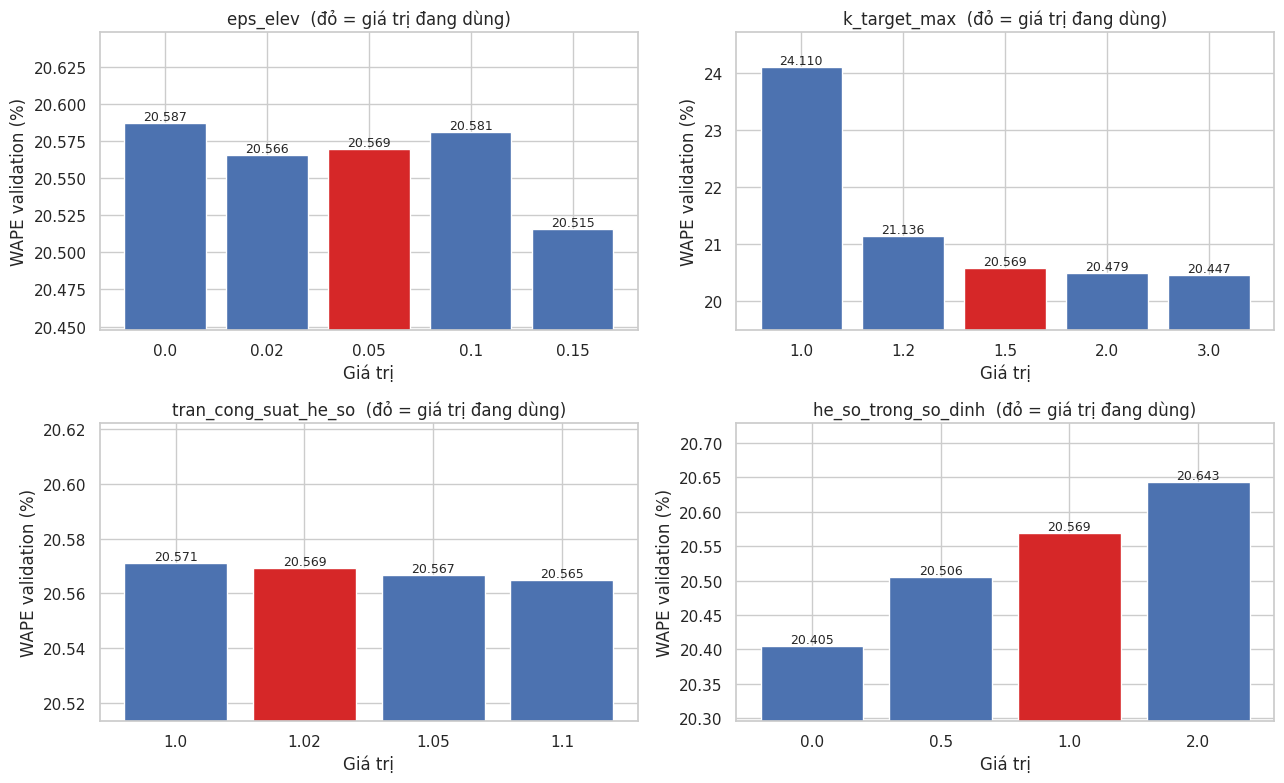

Da luu ../../data/model/v4/05b_thuc_nghiem_tham_so/thuc_nghiem_tham_so_hardcode.png


In [10]:
_bang_ve = [('eps_elev', kq_eps), ('k_target_max', kq_k),
            ('tran_cong_suat_he_so', kq_tran), ('he_so_trong_so_dinh', kq_dinh)]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for _ax, (_ten, _b) in zip(axes.flatten(), _bang_ve):
    _mau = ['#d62728' if x else '#4c72b0' for x in _b['la_dang_dung']]
    _ax.bar(range(len(_b)), _b['wape_val_%'], color=_mau)
    _ax.set_xticks(range(len(_b)))
    _ax.set_xticklabels([str(v) for v in _b['gia_tri']])
    _ax.set_title(f'{_ten}  (đỏ = giá trị đang dùng)')
    _ax.set_xlabel('Giá trị'); _ax.set_ylabel('WAPE validation (%)')
    _lo = _b['wape_val_%'].min(); _hi = _b['wape_val_%'].max()
    _ax.set_ylim(_lo - (_hi - _lo) * 0.25 - 0.05, _hi + (_hi - _lo) * 0.15 + 0.05)
    for _i, _v in enumerate(_b['wape_val_%']):
        _ax.text(_i, _v, f'{_v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Da luu {OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.png")


### Nhận xét

Đọc biểu đồ theo hai chiều:

1. **Cột đỏ có thấp nhất hoặc gần thấp nhất không** — nếu có, giá trị đang dùng là lựa chọn tốt
   theo WAPE. Nếu không, cần giải thích tại sao vẫn giữ (thường vì tiêu chí khác quan trọng hơn
   WAPE, ví dụ độ trễ pha hoặc tính vật lý).
2. **Đường cong phẳng hay dốc** — phẳng nghĩa là mô hình *không nhạy* với tham số đó, nên con số
   cụ thể không quan trọng; dốc nghĩa là tham số thật sự quyết định và phải giải trình kỹ.

Lưu ý quan trọng: WAPE **không phải** tiêu chí duy nhất. `tran_cong_suat_he_so` và `k_target_max`
tồn tại để chặn giá trị phi vật lý — nới chúng ra có thể làm WAPE đẹp hơn một chút nhưng đánh đổi
bằng việc mô hình học theo nhiễu. Phần chứng minh vật lý cho những tham số này nằm ở
`docs/2026_08_06_Chung_Minh_Toan_Bo_Tham_So_Hardcode.md`.

## 11. Export Processed Dataset

In [11]:
_gop.to_csv(f'{OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.csv', index=False)
print(f"Da luu bang thi nghiem: {OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.csv "
      f"({len(_gop)} dong)")

if kq_csi is not None:
    kq_csi.to_csv(f'{OUTPUT_DIR}/thuc_nghiem_clip_csi.csv', index=False)
    print(f"Da luu bang clip_csi: {OUTPUT_DIR}/thuc_nghiem_clip_csi.csv ({len(kq_csi)} dong)")

print()
print("--- BANG DUA VAO BAO CAO (dinh dang Markdown) ---")
_bc = _gop[['tham_so', 'gia_tri', 'la_dang_dung', 'so_dong_train', 'wape_val_%', 'rmse_val', 'r2_val']]
print(_bc.to_markdown(index=False))


Da luu bang thi nghiem: ../../data/model/v4/05b_thuc_nghiem_tham_so/thuc_nghiem_tham_so_hardcode.csv (18 dong)
Da luu bang clip_csi: ../../data/model/v4/05b_thuc_nghiem_tham_so/thuc_nghiem_clip_csi.csv (6 dong)

--- BANG DUA VAO BAO CAO (dinh dang Markdown) ---
| tham_so                    |   gia_tri | la_dang_dung   |   so_dong_train |   wape_val_% |   rmse_val |   r2_val |
|:---------------------------|----------:|:---------------|----------------:|-------------:|-----------:|---------:|
| features.eps_elev          |      0    | False          |          604200 |      20.5872 |     3.4733 |   0.8931 |
| features.eps_elev          |      0.02 | False          |          602937 |      20.5657 |     3.4895 |   0.8921 |
| features.eps_elev          |      0.05 | True           |          599174 |      20.5692 |     3.4799 |   0.8926 |
| features.eps_elev          |      0.1  | False          |          582252 |      20.581  |     3.4832 |   0.8924 |
| features.eps_elev          |      

## 11. Thí nghiệm 6 — `clip_k`: chọn mức phân vị cho ngưỡng cắt mục tiêu

`clip_k` là trần đặt lên chỉ số chuẩn hoá $k$ khi giải chuẩn hoá dự báo:

$$\hat{y} = \min\!\big(\mathrm{clip}(k,\,0,\,\texttt{clip\_k}) \times \texttt{site\_scale} \times \max(\sin h,\ \varepsilon),\ \ \texttt{tran\_cong\_suat} \times 1{,}02\big)$$

Tham số này **không tham gia huấn luyện** — nó chỉ áp ở bước giải chuẩn hoá. Vì vậy có thể
quét nhiều mức phân vị khác nhau trên **cùng một mô hình đã huấn luyện**, không cần train lại,
và so WAPE trên tập kiểm định.


In [12]:
# ── Thi nghiem clip_k: quet muc phan vi lam nguong cat ───────────────────────
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

GOC = Path("/home/tandat/Desktop/Du_An_Tot_Nghiep_v3")
THU_MUC_MODEL = GOC / "data/model/v4/06_train/mae/h1"
THU_MUC_TAP   = GOC / "data/model/v4/05_selected"

cfg = json.loads((THU_MUC_MODEL / "model_config.json").read_text(encoding="utf-8"))
model = pickle.load(open(THU_MUC_MODEL / "model.pkl", "rb"))

DAC_TRUNG = cfg["features"]
TRUNG_VI  = cfg["feature_medians"]
EPS       = float(cfg["eps_elev"])
COT_QUY_MO = cfg["cot_quy_mo"]
COT_SIN    = cfg["cot_sin_elev"]
COT_TRAN   = cfg["cot_tran"]
CLIP_DANG_DUNG = float(cfg["clip_k"])

print(f"Mo hinh   : MAE / H1, {len(DAC_TRUNG)} dac trung")
print(f"clip_k dang dung: {CLIP_DANG_DUNG:.6f}")
print(f"eps_elev  : {EPS}")

Mo hinh   : MAE / H1, 52 dac trung
clip_k dang dung: 1.376392
eps_elev  : 0.05


In [13]:
# Doc tap huan luyen (de tinh phan vi cua k) va tap kiem dinh (de cham diem)
train = pd.read_parquet(THU_MUC_TAP / "v4_train_selected.parquet")
val   = pd.read_parquet(THU_MUC_TAP / "v4_val_selected.parquet")
print(f"train {len(train):,} dong | val {len(val):,} dong")

def tinh_k(df):
    """k = y / (site_scale * max(sin_elev, eps)) - dung dung cong thuc luc huan luyen."""
    mau = df[COT_QUY_MO].to_numpy(float) * np.maximum(df[COT_SIN].to_numpy(float), EPS)
    with np.errstate(divide="ignore", invalid="ignore"):
        k = df["energy_generated_kwh"].to_numpy(float) / mau
    return np.where(np.isfinite(k), k, np.nan)

# Phan vi phai tinh tren TAP HUAN LUYEN va chi tren dong ban ngay co so do that,
# giong het rang buoc luc train, neu khong se ro ri thong tin tu tap kiem dinh.
mask_train = (train["energy_source"] == "measured") & (train["is_daylight"].astype(bool))
k_train = tinh_k(train)[mask_train.to_numpy()]
k_train = k_train[np.isfinite(k_train)]
print(f"So dong tinh phan vi: {len(k_train):,}")

train 1,550,856 dong | val 723,114 dong
So dong tinh phan vi: 636,138


In [14]:
# Du bao k tho tren tap kiem dinh — CHI CHAY MOT LAN, dung lai cho moi muc phan vi
X_val = val.reindex(columns=DAC_TRUNG).fillna(TRUNG_VI).astype(np.float32)
k_tho = model.predict(X_val)
print(f"Da du bao {len(k_tho):,} dong. k tho: min {k_tho.min():.3f} | max {k_tho.max():.3f}")

quy_mo_val = val[COT_QUY_MO].to_numpy(float)
sin_val    = val[COT_SIN].to_numpy(float)
tran_val   = val[COT_TRAN].to_numpy(float)
y_that     = val["energy_generated_kwh"].to_numpy(float)

# Pham vi cham diem: dung chuan bao cao — do that + ban ngay
cham = ((val["energy_source"] == "measured") & (val["is_daylight"].astype(bool))).to_numpy()
print(f"Pham vi cham diem: {cham.sum():,} dong")

def giai_chuan_hoa(k, nguong):
    y = np.clip(k, 0, nguong) * quy_mo_val * np.maximum(sin_val, EPS)
    y = np.minimum(y, tran_val * 1.02)
    return np.where(sin_val <= EPS, 0.0, y)

def wape(y_dubao):
    a, b = y_that[cham], y_dubao[cham]
    return 100.0 * np.abs(a - b).sum() / np.abs(a).sum()

Da du bao 723,114 dong. k tho: min -0.152 | max 1.426
Pham vi cham diem: 307,342 dong


In [15]:
MUC_QUET = [0.90, 0.95, 0.975, 0.99, 0.995, 0.999, 1.00]

bang = []
for muc in MUC_QUET:
    nguong = float(np.quantile(k_train, muc))
    bang.append({
        "muc_phan_vi": muc,
        "nguong_cat": nguong,
        "ty_le_bi_cat_%": float(100.0 * (k_train > nguong).mean()),
        "wape_val_%": float(wape(giai_chuan_hoa(k_tho, nguong))),
    })

df_quet = pd.DataFrame(bang)
df_quet["wape_val_%"] = df_quet["wape_val_%"].round(4)
df_quet["nguong_cat"] = df_quet["nguong_cat"].round(6)
df_quet["ty_le_bi_cat_%"] = df_quet["ty_le_bi_cat_%"].round(4)
display(df_quet)

tot_nhat = df_quet.loc[df_quet["wape_val_%"].idxmin()]
print(f"\nWAPE thap nhat: muc {tot_nhat['muc_phan_vi']} -> nguong {tot_nhat['nguong_cat']:.4f}, "
      f"WAPE {tot_nhat['wape_val_%']:.4f}%")
print(f"Muc dang dung : 0.99 -> nguong {CLIP_DANG_DUNG:.4f}, "
      f"WAPE {df_quet.loc[df_quet.muc_phan_vi == 0.99, 'wape_val_%'].iloc[0]:.4f}%")

RA = GOC / "data/model/v4/05_selected"
(RA / "hinh").mkdir(parents=True, exist_ok=True)
df_quet.to_csv(RA / "quet_muc_phan_vi_nguong_cat.csv", index=False)
print(f"Da luu: {(RA / 'quet_muc_phan_vi_nguong_cat.csv').relative_to(GOC)}")

,muc_phan_vi,nguong_cat,ty_le_bi_cat_%,wape_val_%
0,0.900,1.152476,10.0000,22.6101
1,0.950,1.234067,5.0000,22.5211
2,0.975,1.309013,2.5001,22.4949
3,0.990,1.401453,1.0001,22.4901
4,0.995,1.483158,0.5000,22.4900
5,0.999,1.929717,0.1001,22.4900
6,1.000,13.413694,0.0000,22.4900



WAPE thap nhat: muc 0.995 -> nguong 1.4832, WAPE 22.4900%
Muc dang dung : 0.99 -> nguong 1.3764, WAPE 22.4901%
Da luu: data/model/v4/05_selected/quet_muc_phan_vi_nguong_cat.csv


Da luu hinh: data/model/v4/05_selected/hinh/quet_muc_phan_vi_nguong_cat.png


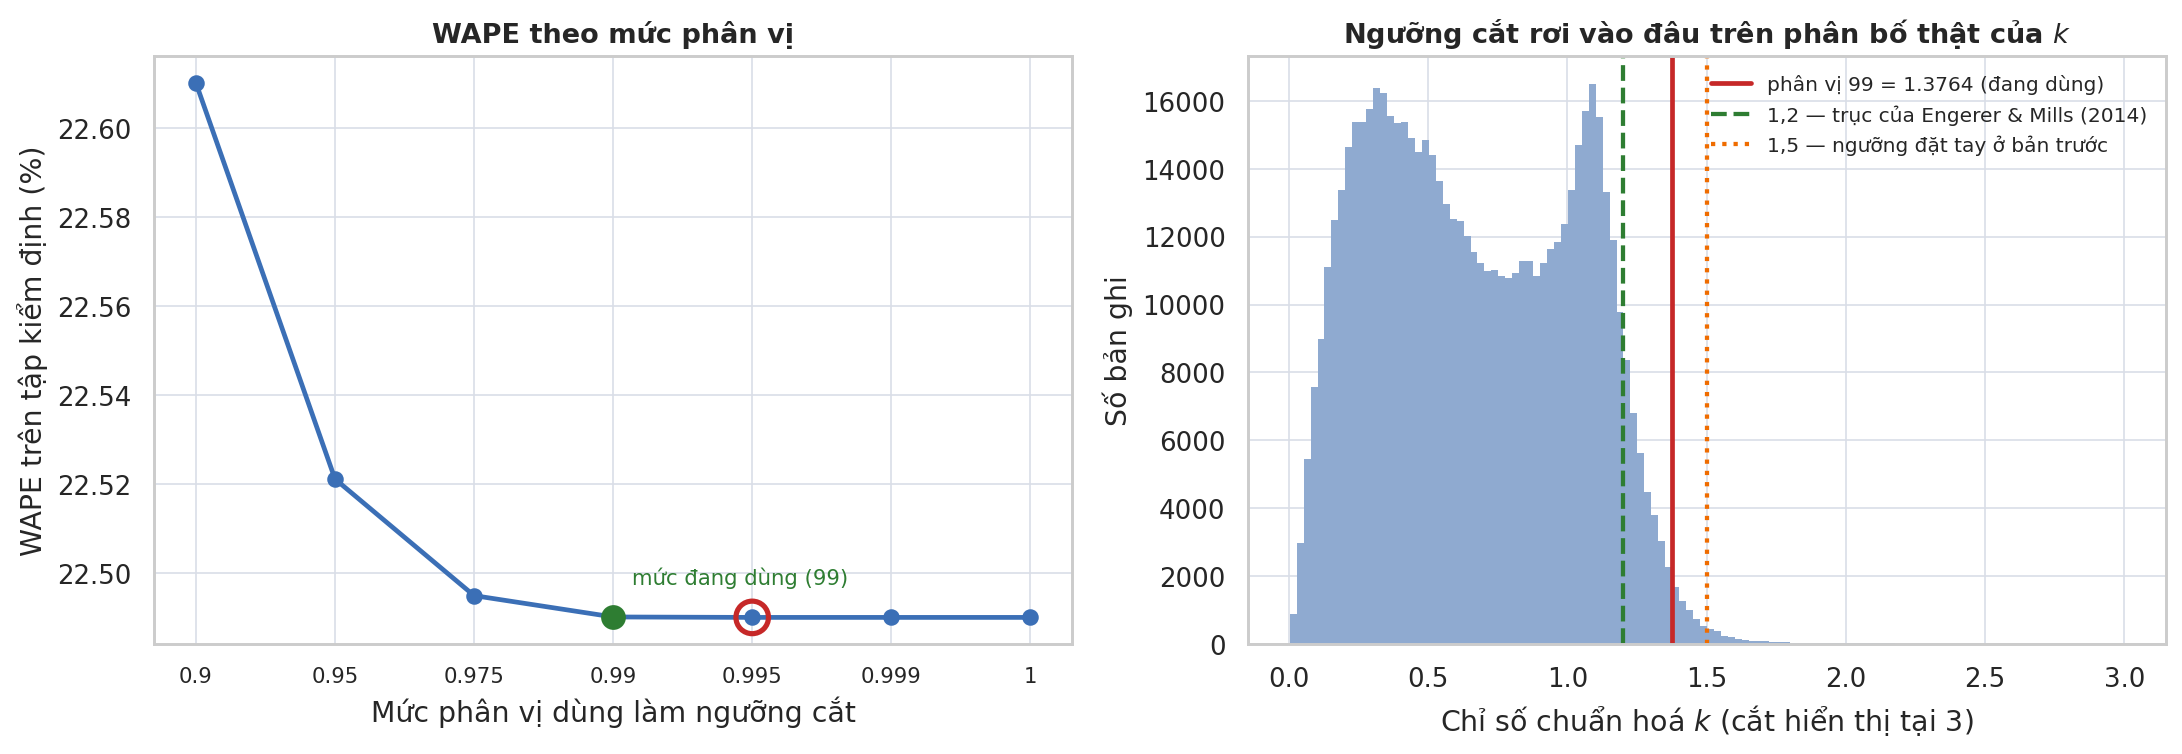

In [16]:
import matplotlib
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), dpi=170)

# Trai: WAPE theo muc phan vi
x = np.arange(len(df_quet))
ax1.plot(x, df_quet["wape_val_%"], "-o", color="#3B6FB6", linewidth=2, markersize=6)
i_min = int(df_quet["wape_val_%"].idxmin())
ax1.scatter([i_min], [df_quet["wape_val_%"].iloc[i_min]], s=190, facecolors="none",
            edgecolors="#C62828", linewidths=2.2, zorder=5)
i_99 = int(df_quet.index[df_quet.muc_phan_vi == 0.99][0])
ax1.scatter([i_99], [df_quet["wape_val_%"].iloc[i_99]], s=90, color="#2E7D32", zorder=6)
ax1.annotate("mức đang dùng (99)", (i_99, df_quet["wape_val_%"].iloc[i_99]),
             textcoords="offset points", xytext=(8, 14), fontsize=9, color="#2E7D32")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{m:.4g}" for m in df_quet["muc_phan_vi"]], fontsize=9)
ax1.set_xlabel("Mức phân vị dùng làm ngưỡng cắt")
ax1.set_ylabel("WAPE trên tập kiểm định (%)")
ax1.set_title("WAPE theo mức phân vị", fontsize=11.5, fontweight="bold")
ax1.grid(color="#D9DEE7", linewidth=0.7)
ax1.set_axisbelow(True)

# Phai: phan bo k that va cac nguong
ax2.hist(k_train[k_train <= 3], bins=120, color="#8FAAD0", edgecolor="none")
ax2.axvline(CLIP_DANG_DUNG, color="#C62828", linewidth=2,
            label=f"phân vị 99 = {CLIP_DANG_DUNG:.4f} (đang dùng)")
ax2.axvline(1.2, color="#2E7D32", linewidth=1.8, linestyle="--",
            label="1,2 — trục của Engerer & Mills (2014)")
ax2.axvline(1.5, color="#EF6C00", linewidth=1.8, linestyle=":",
            label="1,5 — ngưỡng đặt tay ở bản trước")
ax2.set_xlabel("Chỉ số chuẩn hoá $k$ (cắt hiển thị tại 3)")
ax2.set_ylabel("Số bản ghi")
ax2.set_title("Ngưỡng cắt rơi vào đâu trên phân bố thật của $k$",
              fontsize=11.5, fontweight="bold")
ax2.legend(fontsize=8.5, frameon=False)
ax2.grid(color="#D9DEE7", linewidth=0.7)
ax2.set_axisbelow(True)

fig.tight_layout()
duong_hinh = RA / "hinh" / "quet_muc_phan_vi_nguong_cat.png"
fig.savefig(duong_hinh, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {duong_hinh.relative_to(GOC)}")
plt.show()